# Executive Summary
This project analyzes a dataset of bank transactions to uncover patterns in customer behavior, spending habits, and account activity to detect any fraud. The dataset includes detailed records of individual transactions, such as transaction type (e.g., debit, credit, ATM), amount, date, account ID, and merchant category.

### Business Context
Banks and financial institutions rely on transaction data to understand customer engagement, detect fraud, and tailor financial products. By analyzing this data, we aim to identify actionable insights that can improve customer retention, optimize marketing strategies, and enhance operational efficiency.

### Project Objectives
- Segment customers based on transaction behavior.
- Identify peak transaction periods and seasonal trends.
- Compare spending patterns across account types or demographics.
- Test hypotheses about transaction behavior using statistical methods.
  
### Key Techniques Applied
- Data Wrangling: Cleaned and standardized records.
- Exploratory Data Analysis (EDA): Visualized trends and anomalies.
- Hypothesis Testing: Applied ANOVA to compare transaction amounts across various features to detect fraud.
  
### Business Problem/Insights
- Increase in calls of customers mentioning their account is locked and they don't know why or how it happened.
- Increaseing numbers of fraud amount dispute in banks recently.
- Statistically significant differences existing in transaction behavior across account types.

### Findings
- Multiple potential fraud activity detected in the dataset.
- Same device logging into multiple accounts which indicates a potential fraud activity.
- There's high logging attempts into ATM machine from debit card potentially because customers debit cards were skimmed(cloned).
- High number of fraud activity in South Central parts of USA(Fort Worth, Oklahoma City, Charlotte among the highest)
  
### Recommendations
- Create a loyalty programme for high spending customers.
- Monitor outlier transactions for potential fraud.
- Lock customers account after 3 failed login attempts to prevent fraud.
- Make 2-Factor suthentication compulsary while logging in from a new device.
- More testing required for identifying and verifying fraud by using K-means clustering algorithm or similar to divide data into pre-defined clusters to uncover hidden patterns.




In [1]:
!pip install geopy

* Installing geopy to geocode addresses/location for map

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
import matplotlib.colors as mcolors
import folium
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter


## Loading and inspecting dataset

In [3]:
#loading bank transaction dataset
df = pd.read_csv("https://drive.google.com/uc?export=download&id=1Q2khCEkHbo_iVYUtPy42wujyMDwYpLn4")


df.head(10)

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39
5,TX000006,AC00393,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,D000579,117.67.192.211,M054,ATM,18,Student,172,1,781.68,2024-11-04 08:06:36
6,TX000007,AC00199,7.08,2023-02-15 16:36:48,Credit,Seattle,D000241,140.212.253.222,M019,ATM,37,Doctor,139,1,13316.71,2024-11-04 08:10:09
7,TX000008,AC00069,171.42,2023-05-08 17:47:59,Credit,Indianapolis,D000500,92.214.76.157,M020,Branch,67,Retired,291,1,2796.24,2024-11-04 08:10:55
8,TX000009,AC00135,106.23,2023-03-21 16:59:46,Credit,Detroit,D000690,24.148.92.177,M035,Branch,51,Engineer,86,1,9095.14,2024-11-04 08:11:14
9,TX000010,AC00385,815.96,2023-03-31 16:06:57,Debit,Nashville,D000199,32.169.88.41,M007,ATM,55,Doctor,120,1,1021.88,2024-11-04 08:06:32


In [4]:
#Display dataset's information
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  Acc

In [5]:
# Generating descriptive statistics of the DataFrame
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [6]:
df.isnull().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

## Data Wrangling

* Changing column names into snake case format like user_name for clear naming convention

In [7]:
df.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate'],
      dtype='object')

In [8]:
#creating the new column name format
formatted_columns = [
    'transaction_id', 'account_id', 'transaction_amount', 'transaction_date',
    'transaction_type', 'location', 'device_id', 'ip_address', 'merchant_id',
    'channel', 'customer_age', 'customer_occupation', 'transaction_duration',
    'login_attempts', 'account_balance', 'previous_transaction_date'
]

In [9]:
# Applying formatted columns into dataset
df.columns = formatted_columns

# checking columns names again to verify
df.columns

Index(['transaction_id', 'account_id', 'transaction_amount',
       'transaction_date', 'transaction_type', 'location', 'device_id',
       'ip_address', 'merchant_id', 'channel', 'customer_age',
       'customer_occupation', 'transaction_duration', 'login_attempts',
       'account_balance', 'previous_transaction_date'],
      dtype='object')

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

transaction_id               2512
account_id                    495
transaction_amount           2455
transaction_date             2512
transaction_type                2
location                       43
device_id                     681
ip_address                    592
merchant_id                   100
channel                         3
customer_age                   63
customer_occupation             4
transaction_duration          288
login_attempts                  5
account_balance              2510
previous_transaction_date     360
dtype: int64

* standardizing location names for consistency.
* Extracting IP subnet (first part of IP) to estimate origin.

In [12]:
# Standardize location
df['location_clean'] = df['location'].str.strip().str.lower().str.title()

# Extract IP subnet
df['ip_subnet'] = df['ip_address'].str.extract(r'^(\d+\.\d+)')


* Filling missing age group if any with median value and creating 3 different age groups.

In [13]:
# Fill missing ages with median
df['customer_age'] = df['customer_age'].fillna(df['customer_age'].median())

# Bin into age groups
def age_category(age):
    if age <= 20:
        return 'Minor'
    elif age <= 50:
        return 'Adult'
    else:
        return 'Senior'

df['age_group'] = df['customer_age'].apply(age_category)

In [14]:
df.head(10)

,transaction_id,account_id,transaction_amount,transaction_date,transaction_type,location,device_id,ip_address,merchant_id,channel,customer_age,customer_occupation,transaction_duration,login_attempts,account_balance,previous_transaction_date,location_clean,ip_subnet,age_group
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08,San Diego,162.198,Senior
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35,Houston,13.149,Senior
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04,Mesa,215.97,Minor
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06,Raleigh,200.13,Adult
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39,Atlanta,65.164,Adult
5,TX000006,AC00393,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,D000579,117.67.192.211,M054,ATM,18,Student,172,1,781.68,2024-11-04 08:06:36,Oklahoma City,117.67,Minor
6,TX000007,AC00199,7.08,2023-02-15 16:36:48,Credit,Seattle,D000241,140.212.253.222,M019,ATM,37,Doctor,139,1,13316.71,2024-11-04 08:10:09,Seattle,140.212,Adult
7,TX000008,AC00069,171.42,2023-05-08 17:47:59,Credit,Indianapolis,D000500,92.214.76.157,M020,Branch,67,Retired,291,1,2796.24,2024-11-04 08:10:55,Indianapolis,92.214,Senior
8,TX000009,AC00135,106.23,2023-03-21 16:59:46,Credit,Detroit,D000690,24.148.92.177,M035,Branch,51,Engineer,86,1,9095.14,2024-11-04 08:11:14,Detroit,24.148,Senior
9,TX000010,AC00385,815.96,2023-03-31 16:06:57,Debit,Nashville,D000199,32.169.88.41,M007,ATM,55,Doctor,120,1,1021.88,2024-11-04 08:06:32,Nashville,32.169,Senior


* summary of all categorical columns in DataFrame

In [15]:
# Describe categorical columns
categorical_stats = df.describe(include='object').T

# Apply gradient styling to 'freq' column
styled_stats = categorical_stats.style.background_gradient(
    subset=['freq'], cmap='Reds'
).set_properties(**{'color': 'black'})

# Display styled DataFrame
display(styled_stats)


,count,unique,top,freq
transaction_id,2512,2512,TX002496,1
account_id,2512,495,AC00460,12
transaction_date,2512,2512,2023-04-03 16:07:53,1
transaction_type,2512,2,Debit,1944
location,2512,43,Fort Worth,70
device_id,2512,681,D000548,9
ip_address,2512,592,200.136.146.93,13
merchant_id,2512,100,M026,45
channel,2512,3,Branch,868
customer_occupation,2512,4,Student,657


* Debit card has the highest frequency of transaction with the number of 1944.
* Most common channel for transaction is Bank Branch.
* High number of customers are students by occupation.

# Exploratory Data Analysis (EDA)

### creating a bar chart showing transaction volume by location

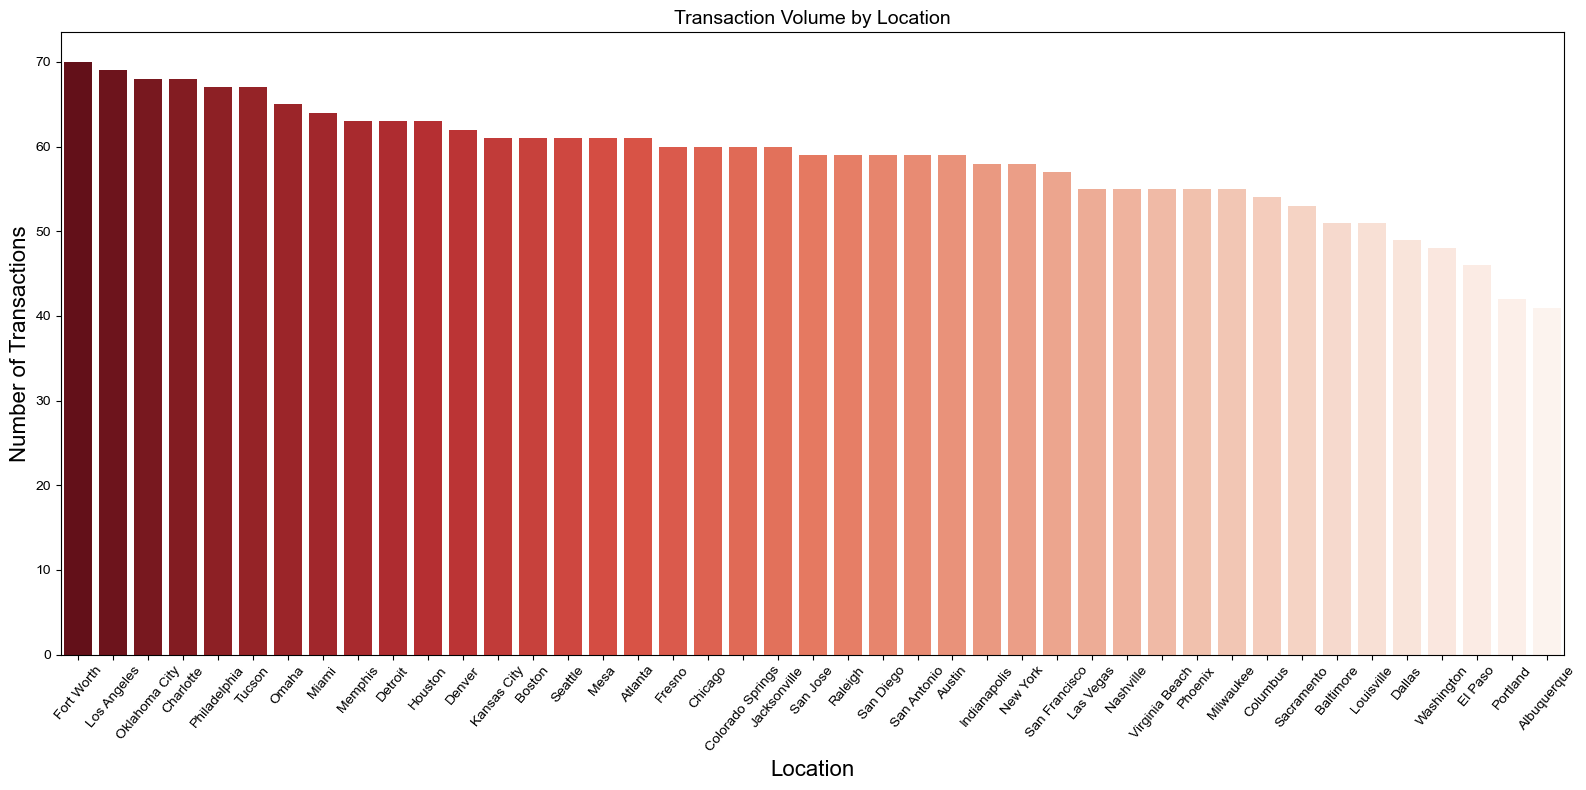

In [16]:
# Group by location and count transactions
location_counts = df['location'].value_counts().reset_index()
location_counts.columns = ['Location', 'Transaction Volume']

# Plotting transaction volume by location
plt.figure(figsize=(16, 8))
sns.barplot(data=location_counts, x='Location', y='Transaction Volume', hue='Location', palette='Reds_r', legend=False)
plt.title('Transaction Volume by Location', fontsize=14)
plt.xlabel('Location', size = 16)
plt.ylabel('Number of Transactions', size = 16)
sns.set_style("whitegrid") 
plt.xticks(rotation=50)
plt.tight_layout()
plt.show()


### Creating a correlation heatmap for all numerical columns in DataFrame.

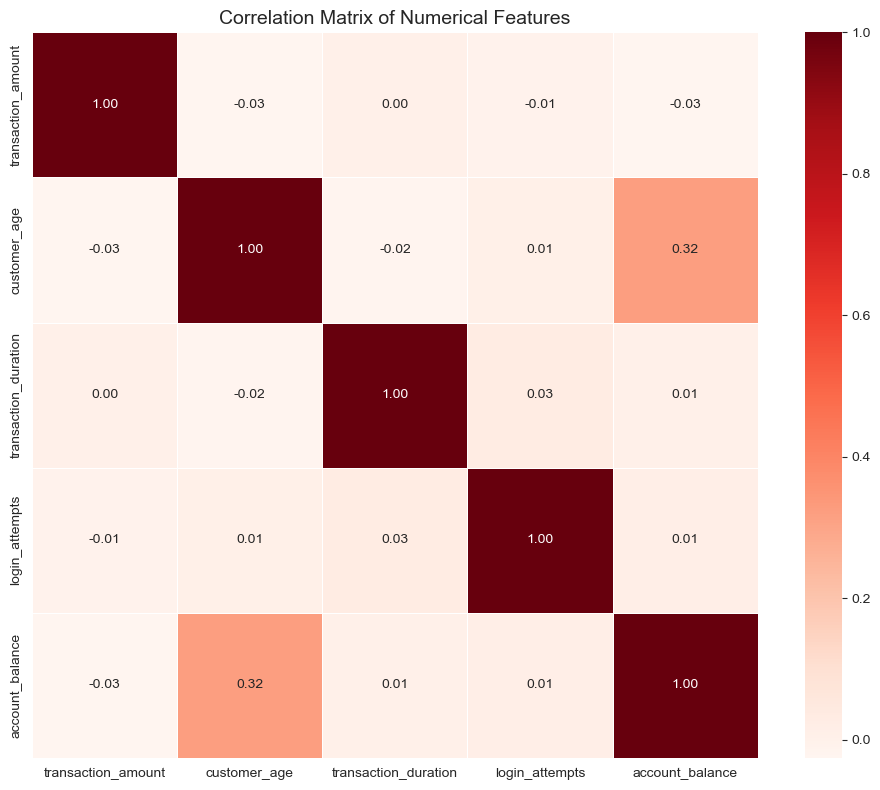

In [17]:
# Select numerical columns
numerical_df = df.select_dtypes(include='number')

# Compute correlation matrix
corr_matrix = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='Reds', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()


* Most of the numericle variables show weak correlation with each other, which indicates variables are relatively independent in terms of linear relationship.

### Creating histogram and boxplot to explore distribution of account balance

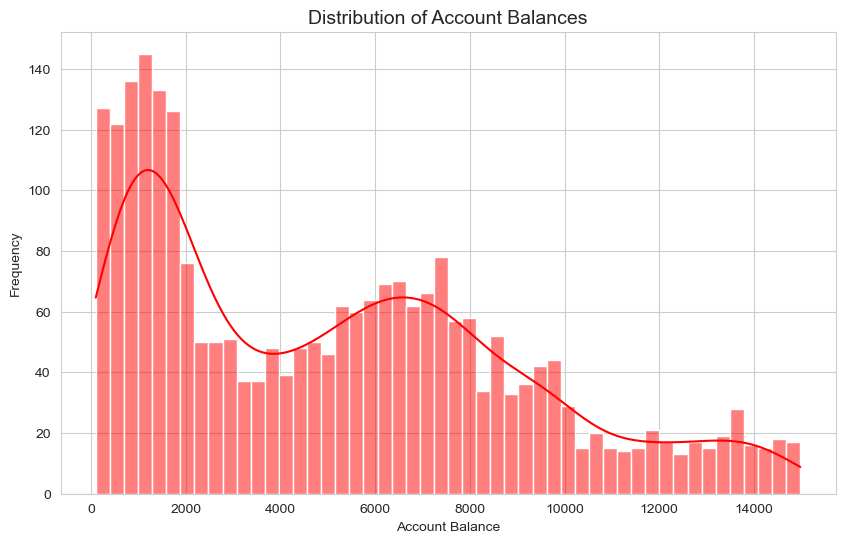

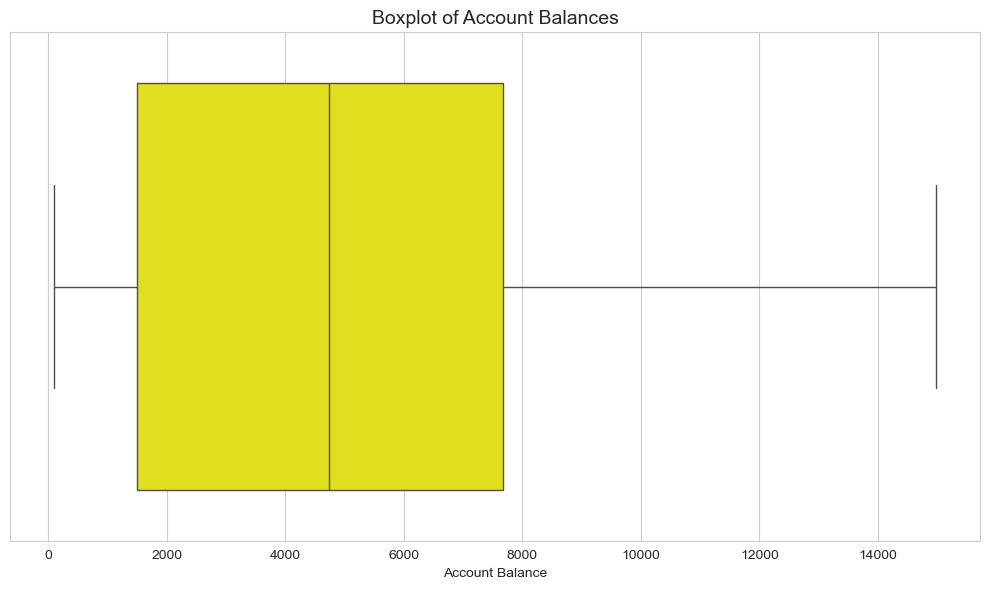

In [18]:
# Plotting distribution of account balances

# Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['account_balance'], bins=50, kde=True, color='red')
plt.title('Distribution of Account Balances', fontsize=14)
plt.xlabel('Account Balance')
plt.ylabel('Frequency')

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['account_balance'], color='yellow')
plt.title('Boxplot of Account Balances', fontsize=14)
plt.xlabel('Account Balance')

# Display both plots
plt.tight_layout()
plt.show()


* The histogram reveals a right-skewed pattern, suggesting that most accounts hold relatively low balances, while a smaller group having higher amounts.

* The box plot further highlights this imbalance, with a pronounced right-side tail pointing to outliers—accounts whose balances far exceed the typical range.


# Visualizing during what time high-value transactions occur during the day.

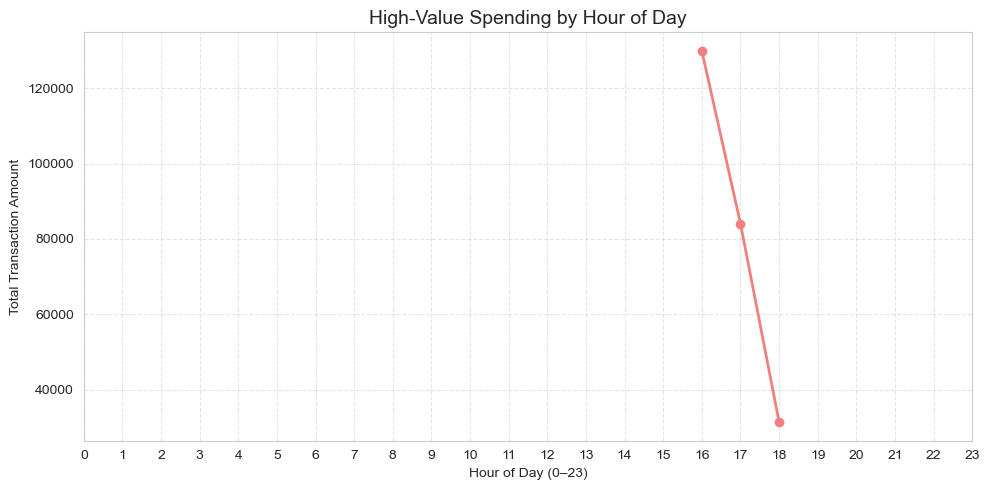

In [19]:
# Convert transaction_date to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Define high-value threshold (top 10%)
threshold = df['transaction_amount'].quantile(0.90)
high_value = df[df['transaction_amount'] >= threshold].copy()   # copy to avoid affecting original DF

# assign hour using .loc
high_value.loc[:, 'hour'] = high_value['transaction_date'].dt.hour  #adds a new column called hour to the high_value DataFrame:

# calculate total high-value spending per hour of the day:
hourly_spending = high_value.groupby('hour')['transaction_amount'].sum()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(hourly_spending.index, hourly_spending.values, marker='o', color='lightcoral', linewidth=2)
plt.title('High-Value Spending by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day (0–23)')
plt.ylabel('Total Transaction Amount')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


* It indicates high value transactions occur between 4PM-6PM which could be due to customer's going shopping or drinking/eating after work hours.

###  Visualizes how many transactions occur on each day of the week.

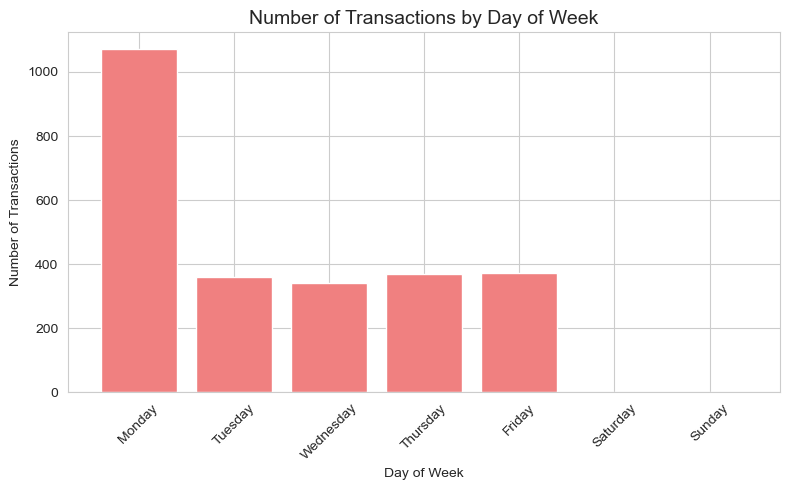

In [20]:
# Convert transaction_date to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract day of week name
df['day_of_week'] = df['transaction_date'].dt.day_name()

# Count transactions per day
day_counts = df['day_of_week'].value_counts()

# Reorder days to start from Monday
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = day_counts.reindex(weekday_order, fill_value=0)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(day_counts.index, day_counts.values, color='lightcoral')
plt.title('Number of Transactions by Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


* Highests number of transactions occurs on Monday and then gradually it evens out during the rest of the week days.
* Weekends have non-existane (very-low) transactions, potentially due to people spending time with family.

### creating a regression plot to visualize the relationship between customer_age and account_balance

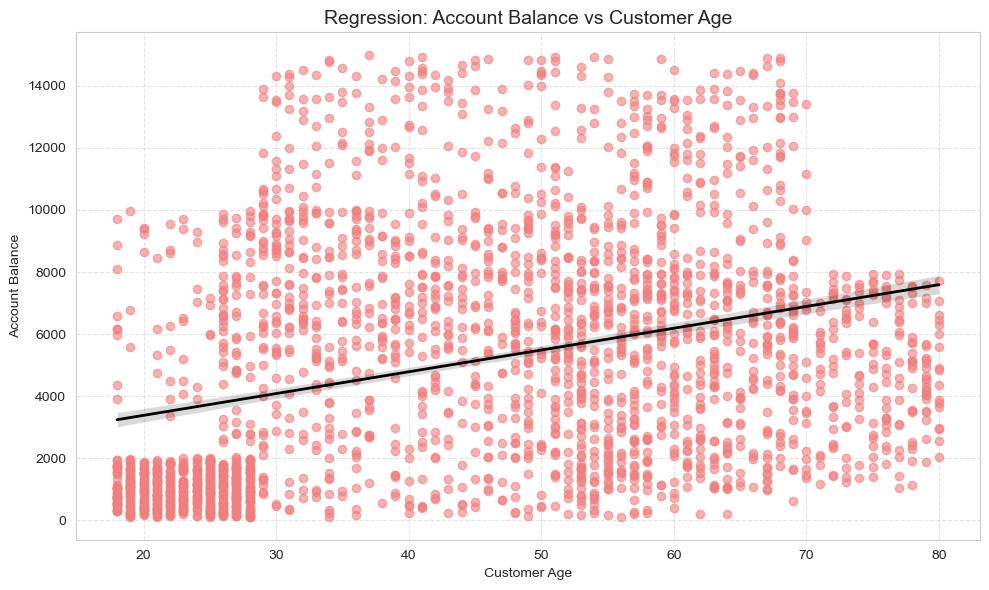

In [21]:
# Plot regression
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x='customer_age',
    y='account_balance',
    scatter_kws={'alpha': 0.6, 'color': 'lightcoral'},
    line_kws={'color': 'black', 'linewidth': 2}
)

plt.title('Regression: Account Balance vs Customer Age', fontsize=14)
plt.xlabel('Customer Age')
plt.ylabel('Account Balance')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


* It shows a positive correlation between customer age and account balance.
* As the age increases, so does their account balance which accumulates over time.
* There are some outliers where people have high amount of balance which could have come from family inheritance or business.
* There are a group of customers who have low account balance even on higher age category.

### Pie chart showing the proportion of Debit vs Credit transactions in dataset

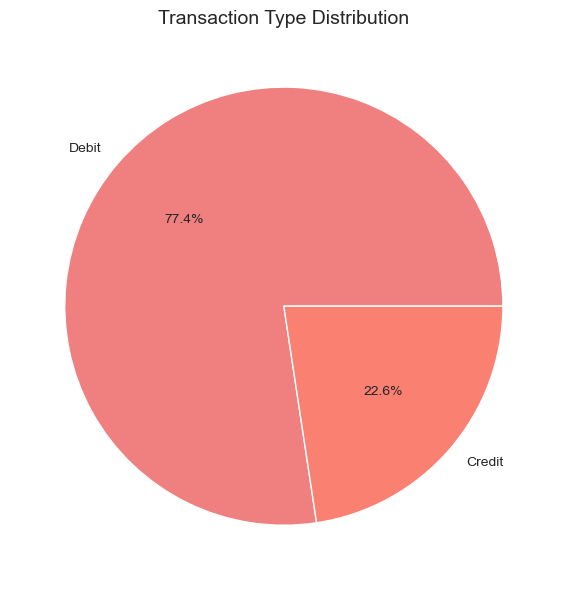

In [22]:
# Pie chart of transaction types (Debit and Credit)
type_counts = df['transaction_type'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'salmon'])
plt.title('Transaction Type Distribution', fontsize=14)
plt.tight_layout()
plt.show()


* Pie chart above Shows Debit transactions account for 77.4% of the total transactions, while Credit transactions accounts for only 22.6%.

### TreeMap showing how transactions are distributed across different transaction channels

In [23]:
!pip install squarify

* Installing squarify to plot TreeMap

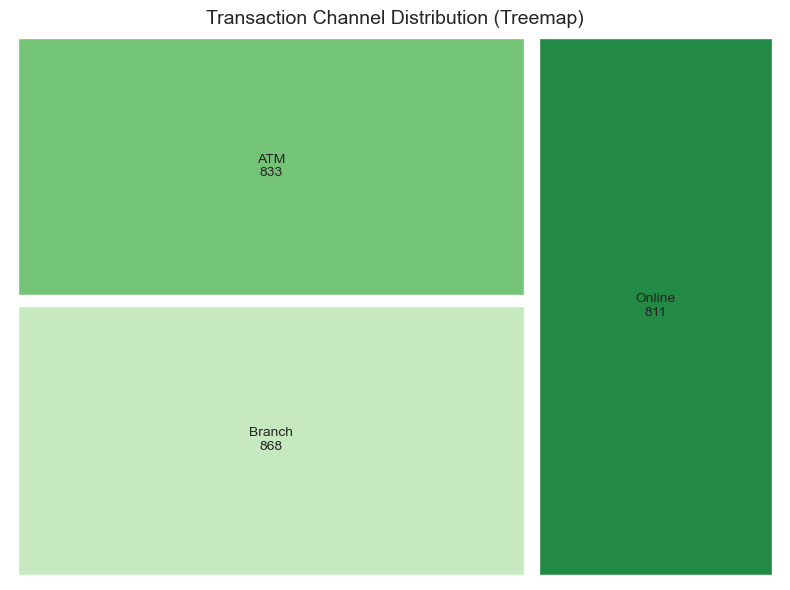

In [24]:
import squarify

# Prepare data
channel_counts = df['channel'].value_counts()
labels = [f'{label}\n{count}' for label, count in zip(channel_counts.index, channel_counts.values)]

# Plot treemap
plt.figure(figsize=(8, 6))
squarify.plot(sizes=channel_counts.values, label=labels, color=sns.color_palette('Greens', len(channel_counts)), pad=True)
plt.title('Transaction Channel Distribution (Treemap)', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()



* TreeMap shows an almost even propotion of transaction between all channels menthods with Branch coming in as most favourable method.


### creating an interactive map showing the geographic locations of transactions using Folium and geocoding

In [25]:
# Geocode location names
geolocator = Nominatim(user_agent="geoapiKapil")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# Create a lookup dictionary for coordinates
location_coords = {}
for loc in df['location'].dropna().unique():
    try:
        geo = geocode(loc)
        if geo:
            location_coords[loc] = (geo.latitude, geo.longitude)
    except:
        continue

# Create base map centered on USA
m = folium.Map(location=[37.0902, -95.7129], zoom_start=4)

# Add hoverable markers using Folium.Marker + tooltip
for loc, coords in location_coords.items():
    folium.Marker(
        location=coords,
        tooltip=loc,  # Hover text
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(m)

# Display map
m


### Bar chart showing how many customers belong to each occupation category

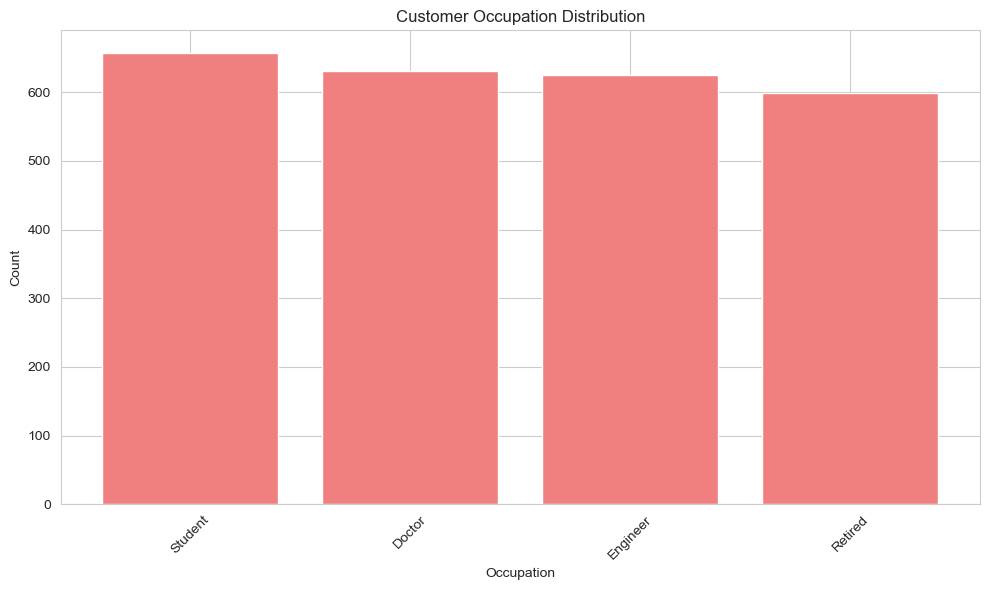

In [26]:
# Count occupations
counts = df['customer_occupation'].value_counts()
x = np.arange(len(counts))
y = counts.values

# Plot bar chart
plt.figure(figsize=(10, 6))
plt.bar(x, y, color='lightcoral')

# Labels and formatting
plt.xticks(x, counts.index, rotation=45)
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.title('Customer Occupation Distribution')
plt.tight_layout()
plt.show()


* Highest numbers of customer occupation on the data is Student's followed by Doctor's, Engineer's and Retired customers.

###  Creating a histogram to visualize the distribution of customer_age in dataset.

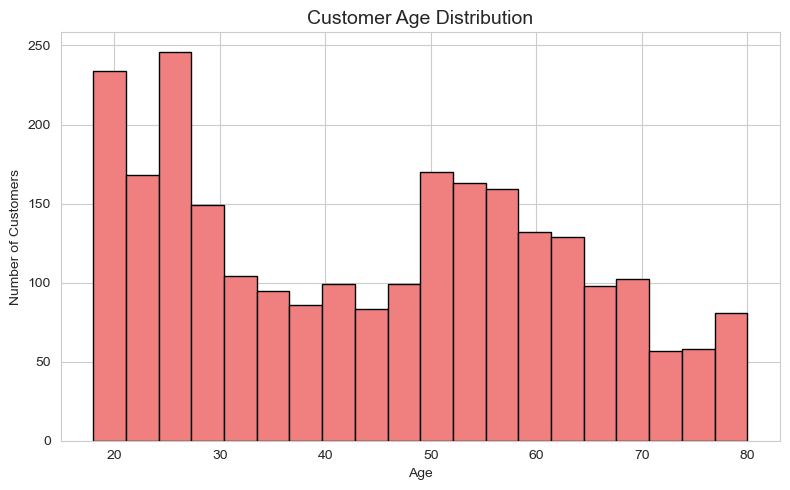

In [27]:
# Plot histogram of customer age
plt.figure(figsize=(8, 5))
plt.hist(df['customer_age'], bins=20, color='lightcoral', edgecolor='black')
plt.title('Customer Age Distribution', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


* It illustrates that there is high number of customers between 20-30 age range followed by a slight decline in age category until age 50 where customer numbers increases again from age range 50-58 and then there is a slow decline again.

### Analyzes and visualizes transaction volume over time: daily, weekly, and monthly


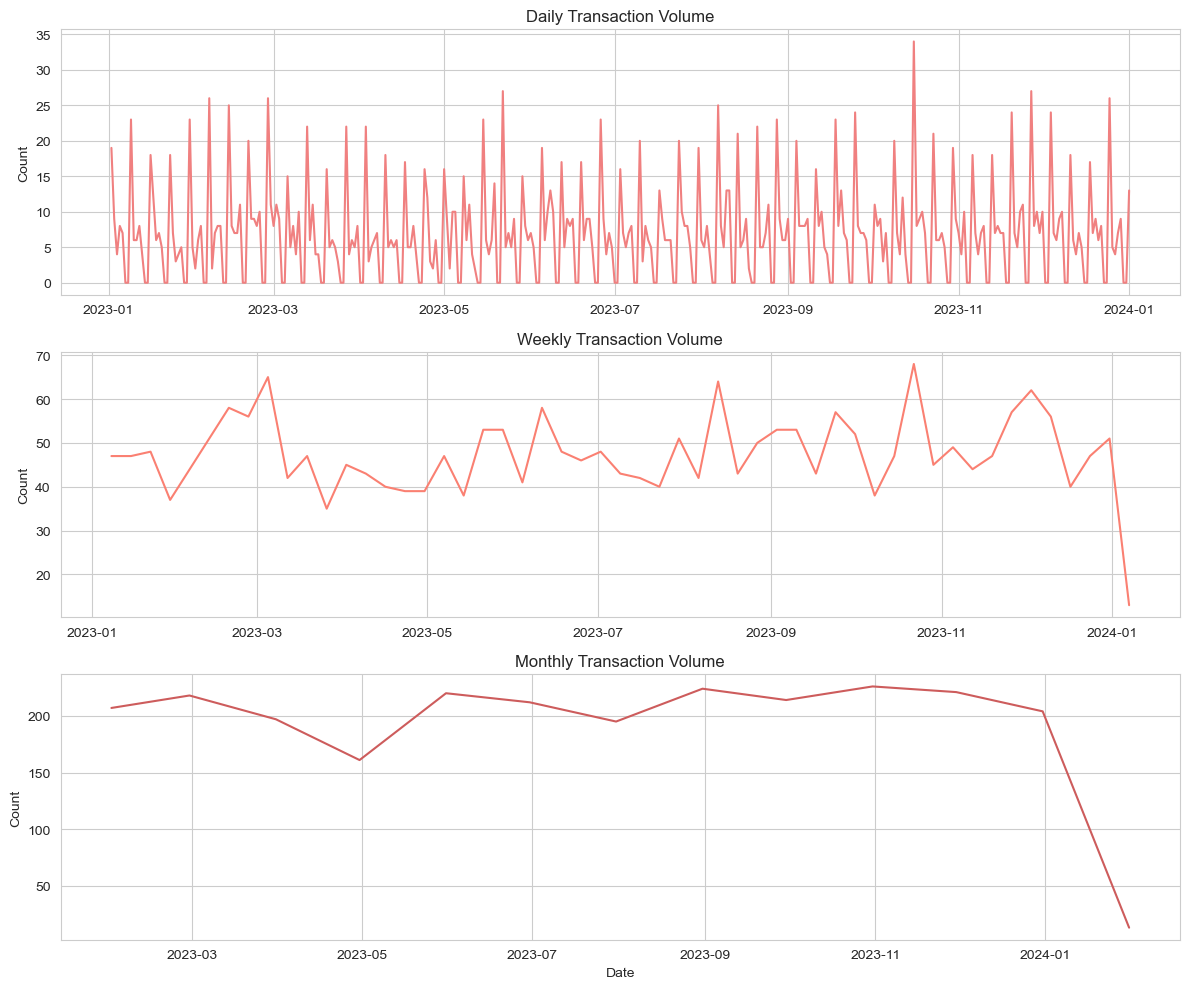

In [28]:
# Convert transaction_date to datetime format
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df.set_index('transaction_date', inplace=True) # sets as dataframe index to enable time-based resampling

# Resample for daily, weekly and monthly counts
daily_volume = df['transaction_amount'].resample('D').count()
weekly_volume = df['transaction_amount'].resample('W').count()
monthly_volume = df['transaction_amount'].resample('ME').count()

# Plot
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

# Daily plot
axs[0].plot(daily_volume.index, daily_volume.values, color='lightcoral')
axs[0].set_title('Daily Transaction Volume')
axs[0].set_ylabel('Count')

# Weekly plot
axs[1].plot(weekly_volume.index, weekly_volume.values, color='salmon')
axs[1].set_title('Weekly Transaction Volume')
axs[1].set_ylabel('Count')

# Monthly plot
axs[2].plot(monthly_volume.index, monthly_volume.values, color='indianred')
axs[2].set_title('Monthly Transaction Volume')
axs[2].set_ylabel('Count')
axs[2].set_xlabel('Date')

plt.tight_layout()
plt.show()


* Daily transactions reveals lots of ups and downs which captures short term spikes of transactions on day to day basis.
* Weekly transactions shows some weeks customers are spending more money and some weeks they are slowing down on spending. Most notable here would 2 big spikes around Ester and Christmas time where there is high amount of transactions on weekly basis.
* Monthly transactions are most stable and least noisy to look at where there is almost an even spending on a monthly basis with a sharp decline in transactions on month of May. There is a very sharp decline on January 2024 which could be due to insufficient data for that month.

### Visualize the distribution of high-value transactions (top 10%) across different transaction types(Credit and Debit) using KDE plot

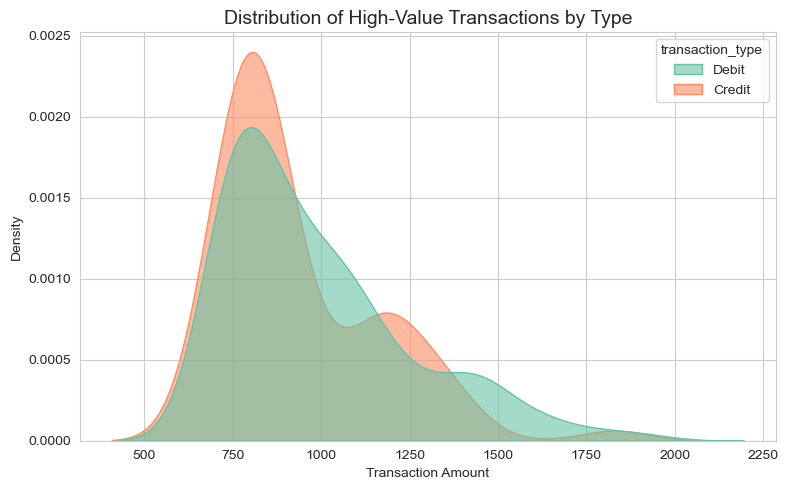

In [29]:
# Define top range (e.g., top 1% of transaction amounts)
threshold = df['transaction_amount'].quantile(0.90)
top_transactions = df[df['transaction_amount'] >= threshold]


# Plot density by transaction type
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=top_transactions,
    x='transaction_amount',
    hue='transaction_type',
    fill=True,
    common_norm=False,
    palette='Set2',
    alpha=0.6
)
plt.title('Distribution of High-Value Transactions by Type', fontsize=14)
plt.xlabel('Transaction Amount')

plt.tight_layout()
plt.show()


* customers are using credit card to spend higher amount of money rather than using debit cards.
* It is a right-skewed plot (positively plot)

### creating a stacked histogram showing how high-value transactions (top 10%) are distributed across different channels

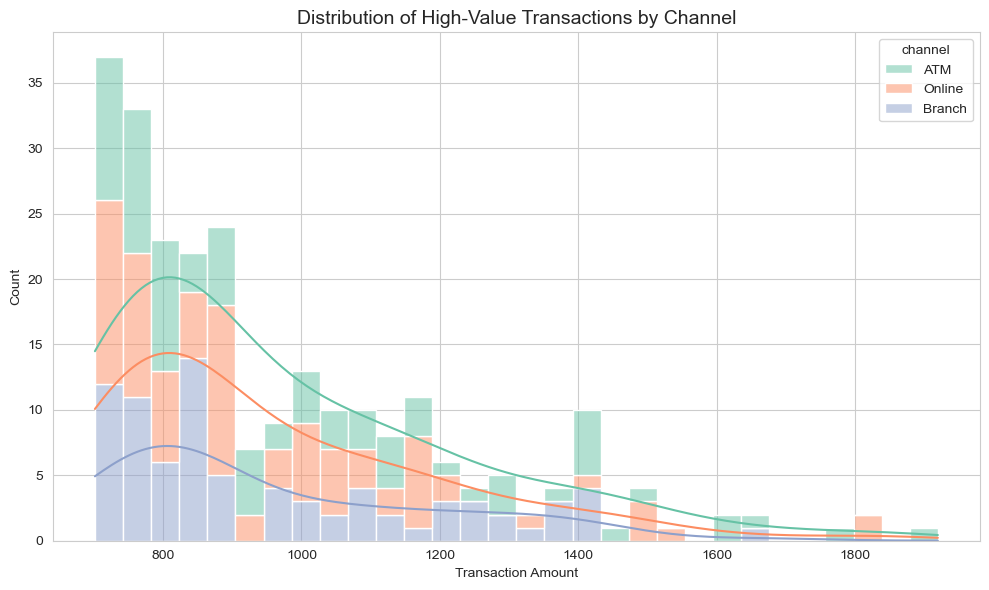

In [30]:
# Define high-value threshold (e.g., top 10%)
threshold = df['transaction_amount'].quantile(0.90)
high_value = df[df['transaction_amount'] >= threshold]

# Plot stacked histogram
plt.figure(figsize=(10, 6))
sns.histplot(
    data=high_value,
    x='transaction_amount',
    hue='channel',
    multiple='stack',
    bins=30,
    kde=True,
    palette='Set2'
)

# Customize labels and legend

plt.title('Distribution of High-Value Transactions by Channel', fontsize=14)
plt.xlabel('Transaction Amount')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


* ATM dominates on transaction by channel on high-value transactions.
* Branch has the lowest number of transaction for high-value transactions.
* It is a right skewed histogram with high numbers of transactions sitting in lower end.

### create a line chart showing the average amount of high-value transactions (top 10%) for each customer occupation.

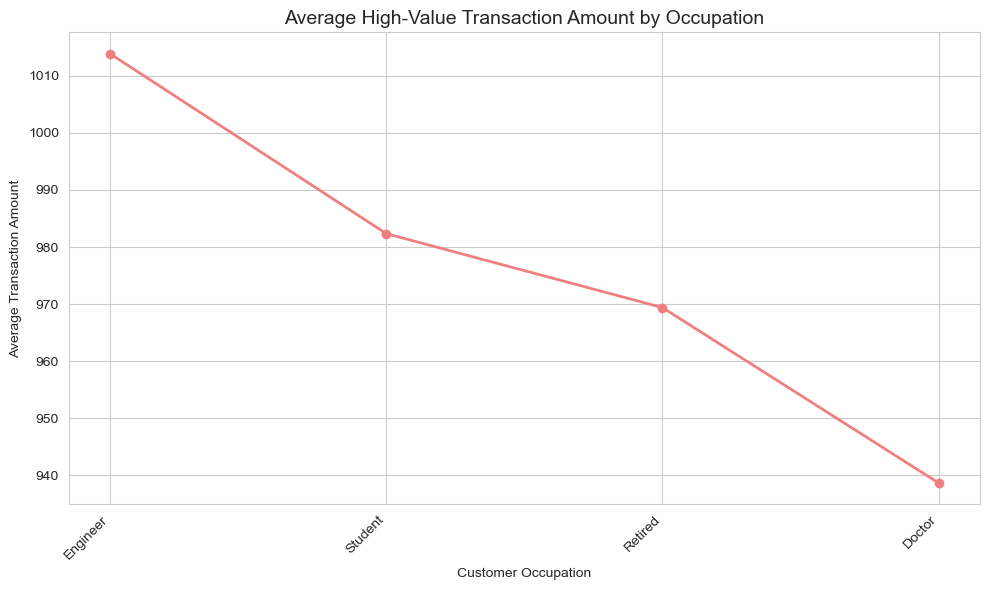

In [31]:

# Define high-value threshold (e.g., top 10%)
threshold = df['transaction_amount'].quantile(0.90)
high_value = df[df['transaction_amount'] >= threshold]

# Group by occupation and calculate average transaction amount
grouped = high_value.groupby('customer_occupation')['transaction_amount'].mean().sort_values(ascending=False)

# Plot line chart
plt.figure(figsize=(10, 6))
plt.plot(grouped.index, grouped.values, marker='o', color='lightcoral', linewidth=2)
plt.title('Average High-Value Transaction Amount by Occupation', fontsize=14)
plt.xlabel('Customer Occupation')
plt.ylabel('Average Transaction Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


* Engineer's have highest numbers of high-value transaction amounts by occupation.
* Doctor's have lowest value transaction amount in the data by occupation.
* Student's and retired have almost similar high-valur transaction amounts only differenciating by around $15.

### create a bar chart showing the top 10 merchants with the highest total transaction amounts

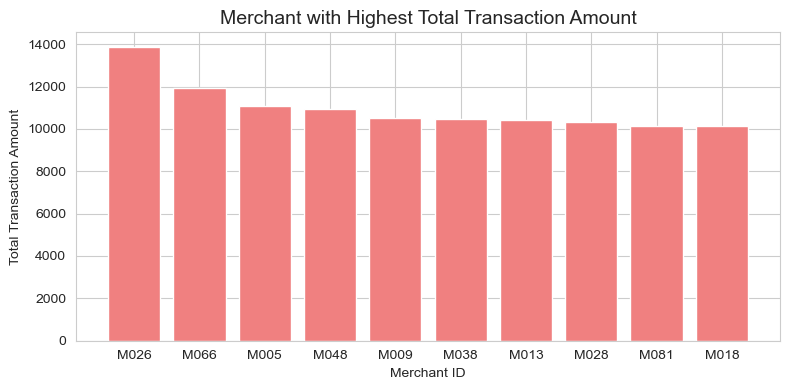

In [32]:
# Group by merchant and sum transaction amounts
merchant_totals = df.groupby('merchant_id')['transaction_amount'].sum().sort_values(ascending=False)

# Get top merchant
top_merchant = merchant_totals.head(10)

# Plot
plt.figure(figsize=(8, 4))
plt.bar(top_merchant.index.astype(str), top_merchant.values, color='lightcoral')
plt.title('Merchant with Highest Total Transaction Amount', fontsize=14)
plt.xlabel('Merchant ID')
plt.ylabel('Total Transaction Amount')
plt.tight_layout()
plt.show()


* Merchant M026 has the highest total transaction amount.
* Almost $200 less than merchant M026, in second place comes Merchant M066.
* Rest of the merchants have almost similar total transaction amounts.

### create a bar chart showing the total transaction amount for each transaction type

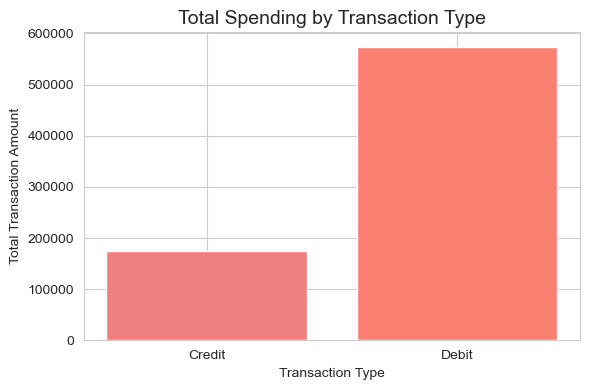

In [33]:
# Group by transaction type and sum transaction amounts
spending_by_type = df.groupby('transaction_type')['transaction_amount'].sum()

# Plot bar chart
plt.figure(figsize=(6, 4))
plt.bar(spending_by_type.index, spending_by_type.values, color=['lightcoral', 'salmon'])
plt.title('Total Spending by Transaction Type', fontsize=14)
plt.xlabel('Transaction Type')
plt.ylabel('Total Transaction Amount')
plt.tight_layout()
plt.show()


* Debit cards have the highest number of total spending by transaction type.
* Even though people use credit card for high transaction amount( shown in previous plot), people prefer to use debit card for day to day basis for smaller transactions which has almost triple the total spending than credit card.

###  create a scatterplot to explore the relationship between login attempts and transaction amounts

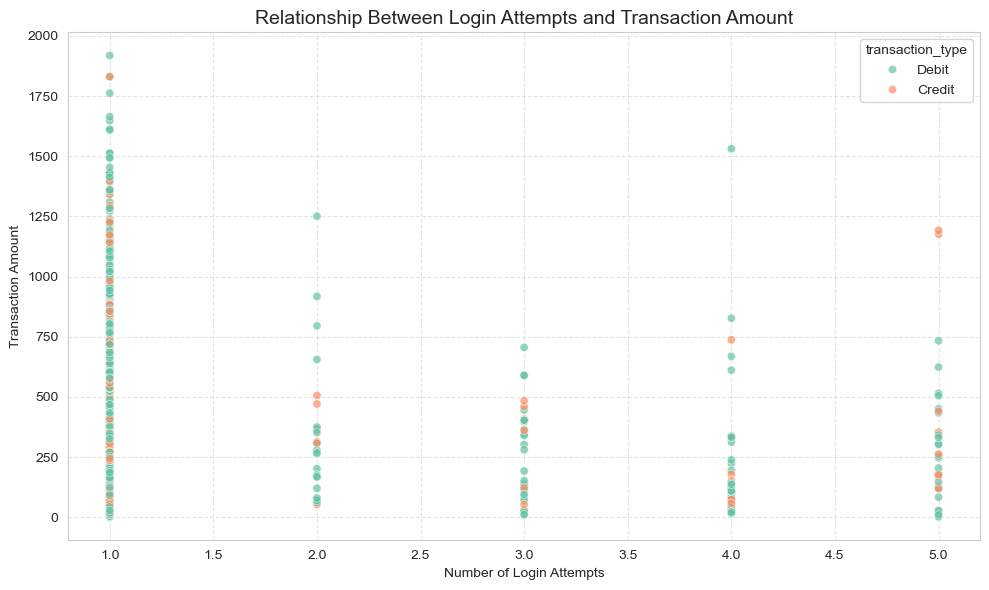

In [34]:
# Plot scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='login_attempts',
    y='transaction_amount',
    hue='transaction_type',  # Optional: color by Credit/Debit
    palette='Set2',
    alpha=0.7
)

plt.title('Relationship Between Login Attempts and Transaction Amount', fontsize=14)
plt.xlabel('Number of Login Attempts')
plt.ylabel('Transaction Amount')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


* Most transactions are going though with 1 login attempts.
* There are few high value transactions(outliers) with multiple login attempts, potentially a fraud or authentication issue.
* There are multiple number of attempts to failed ogin attempts, another potential for a fraud or authentication issue.
  

### create a grouped bar chart that shows how often high login attempts (top 10%) occur across different transaction types and channels.

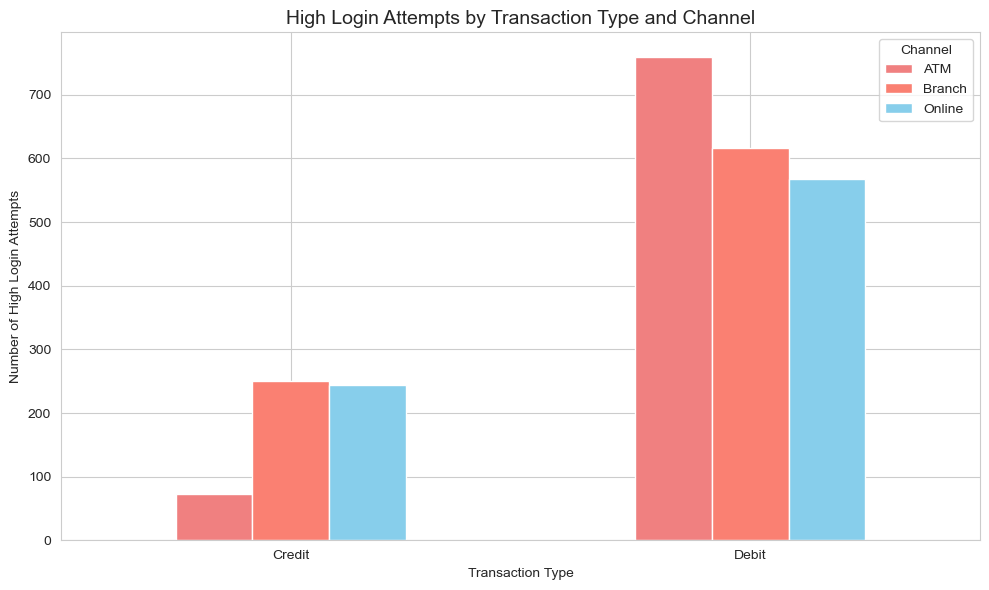

In [35]:
# Define high login attempt threshold (top 10%)
threshold = df['login_attempts'].quantile(0.90)
high_login = df[df['login_attempts'] >= threshold]

# Group by transaction type and channel
grouped = high_login.groupby(['transaction_type', 'channel']).size().unstack(fill_value=0)

# Plot grouped bar chart
grouped.plot(kind='bar', figsize=(10, 6), color=['lightcoral', 'salmon', 'skyblue'])

plt.title('High Login Attempts by Transaction Type and Channel', fontsize=14)
plt.xlabel('Transaction Type')
plt.ylabel('Number of High Login Attempts')
plt.legend(title='Channel')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


* ATM has the highest login attempts on transaction type and channel.
* Credit cards have lower login attempts than debit cards, which means they are more safer than debit cards.
* Credit card on ATM machine has the lowest login attempts by transaction type and channel.

### create a horizontal bar chart showing the top 5 locations with the highest number of high login attempts (top 10% of login counts)

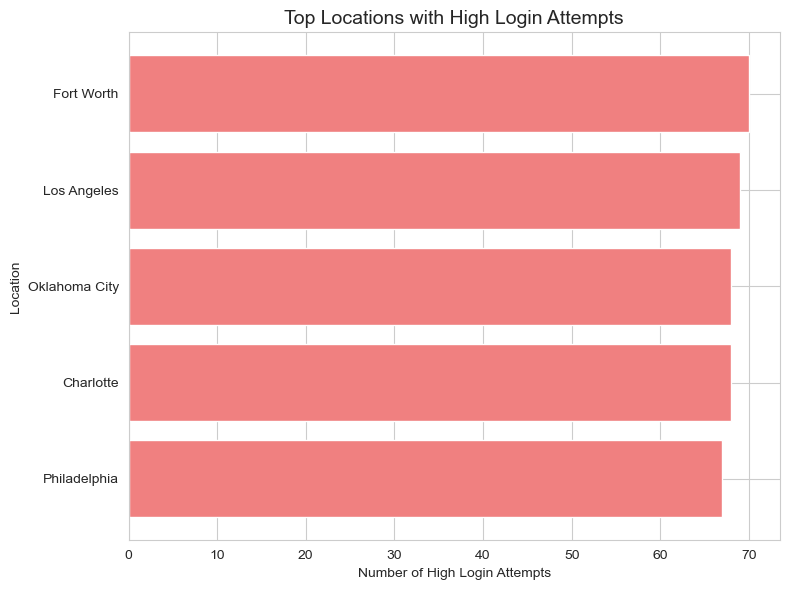

In [36]:
# Define high login attempt threshold (top 10%)
threshold = df['login_attempts'].quantile(0.90)
high_login = df[df['login_attempts'] >= threshold]

# Count locations
location_counts = high_login['location'].value_counts().head(5)  # top 10 locations

# Plot
plt.figure(figsize=(8, 6))
plt.barh(location_counts.index[::-1], location_counts.values[::-1], color='lightcoral')
plt.title('Top Locations with High Login Attempts', fontsize=14)
plt.xlabel('Number of High Login Attempts')
plt.ylabel('Location')
plt.tight_layout()
plt.show()


* High number of fraud activity in South Central parts of USA(Fort Worth, Oklahoma City, Charlotte)
* Login attempts are exceeding a very high number which is not a sign of authentication issue at this point but a potentially targeted fraud.

### create a horizontal bar chart showing the top 10 devices that have been used to access multiple unique accounts

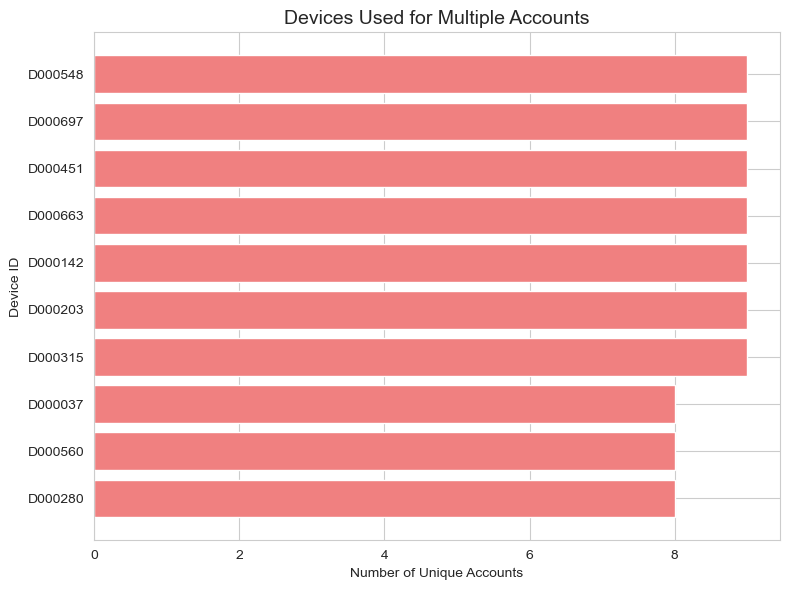

In [37]:
# Count unique accounts per device
device_account_counts = df.groupby('device_id')['account_id'].nunique()

# Filter devices used for multiple accounts
multi_account_devices = device_account_counts[device_account_counts > 1].sort_values(ascending=False)

# Select top 10 for visualization
top_devices = multi_account_devices.head(10)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(top_devices.index[::-1].astype(str), top_devices.values[::-1], color='lightcoral')
plt.title('Devices Used for Multiple Accounts', fontsize=14)
plt.xlabel('Number of Unique Accounts')
plt.ylabel('Device ID')
plt.tight_layout()
plt.show()


* Same devices are being used to login to multiple account id's.
* Multiple devices are being used to login to more than 8 different accounts on each one of them.
* More than 7 devices are being to login to 9 different account id's.

# Hypothesis testing

* One-way ANOVA (Analysis of Variance) test among different groups to detect fraud transaction attempts.

In [38]:
import statsmodels.api as sm
from statsmodels.formula.api import ols


# Create frequency features
device_freq = df['device_id'].value_counts().rename_axis('device_id').reset_index(name='device_freq_count')
account_freq = df['account_id'].value_counts().rename_axis('account_id').reset_index(name='account_freq_count')
df = df.merge(device_freq, on='device_id', how='left')
df = df.merge(account_freq, on='account_id', how='left')

# Create potential fraud flag
df['potential_fraud'] = (
    (df['login_attempts'] > 3) |
    (df['transaction_amount'] > 10000) |
    (df['device_freq_count'] > df['device_freq_count'].quantile(0.95))
).astype(int)

# Select numeric features for ANOVA
features = ['login_attempts', 'transaction_amount', 'account_balance', 'device_freq_count', 'account_freq_count']

print(" One-Way ANOVA Results (Potential Fraud vs Normal)\n")
for feature in features:
    model = ols(f'{feature} ~ C(potential_fraud)', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    f_val = anova_table['F'].iloc[0]
    p_val = anova_table['PR(>F)'].iloc[0]
    print(f"{feature}: F-statistic = {f_val:.4f}, p-value = {p_val:.4f}")


 One-Way ANOVA Results (Potential Fraud vs Normal)

login_attempts: F-statistic = 1712.2298, p-value = 0.0000
transaction_amount: F-statistic = 0.1538, p-value = 0.6950
account_balance: F-statistic = 0.1004, p-value = 0.7514
device_freq_count: F-statistic = 197.8770, p-value = 0.0000
account_freq_count: F-statistic = 0.1991, p-value = 0.6555


### Results

* we can see login_attempts had strong evidance of difference between potential fraud and normal transaction
* device_freq_count gives more evidance of potential fraud transactions.
* These could be key fraud indicators worth modeling or flagging.

In [39]:
df.head

<bound method NDFrame.head of      transaction_id account_id  transaction_amount transaction_type  \
0          TX000001    AC00128               14.09            Debit   
1          TX000002    AC00455              376.24            Debit   
2          TX000003    AC00019              126.29            Debit   
3          TX000004    AC00070              184.50            Debit   
4          TX000005    AC00411               13.45           Credit   
...             ...        ...                 ...              ...   
2507       TX002508    AC00297              856.21           Credit   
2508       TX002509    AC00322              251.54            Debit   
2509       TX002510    AC00095               28.63            Debit   
2510       TX002511    AC00118              185.97            Debit   
2511       TX002512    AC00009              243.08           Credit   

              location device_id      ip_address merchant_id channel  \
0            San Diego   D000380  162.198.218

In [40]:
# Count how many rows are flagged as fraud
fraud_count = df[df['potential_fraud'] == 1].shape[0]

# Print result
if fraud_count > 0:
    print(f"Found {fraud_count} potential fraud-flagged rows in the dataset.")
else:
    print("No fraud-flagged rows found in the dataset.")

Found 127 potential fraud-flagged rows in the dataset.
